## Week5: Convolutional Neural Networks (CNNs) for Images and Signals

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. In this session, we will delve into the world of Convolutional Neural Networks (CNNs) and explore their application in two distinct domains: image classification and 1-dimensional signal analysis. We will use the TensorFlow and Keras libraries to build, train, and evaluate CNN models for these tasks.

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, Callback
from IPython.display import clear_output

In [12]:
class PlotLosses(Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.fig = plt.figure()

        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        clear_output(wait=True)
        plt.plot(self.x, self.losses, label="loss")
        plt.plot(self.x, self.val_losses, label="val_loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.show()

plot_losses = PlotLosses()

# Part 1: 2D CNN for Image Classification (Fashion MNIST)

### In the first part of this notebook, we will build a 2D CNN for image classification using the Fashion MNIST dataset. We will use TensorFlow and Keras to build the model.We will also visualize the training process and evaluate the model on the test set.

### Understanding the Fashion MNIST Dataset:

The Fashion MNIST dataset is a popular benchmark dataset for image classification. It was created as a more challenging replacement for the original MNIST dataset of handwritten digits. Fashion MNIST consists of 70,000 grayscale images (28x28 pixels) of 10 fashion categories, with 7000 images per category. The dataset is split into 60,000 training images and 10,000 testing images.

**The 10 classes in Fashion MNIST are:**

0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

Each image is a 28x28 pixel grayscale image, meaning each pixel has a single intensity value ranging from 0 to 255. The goal is to build a model that can correctly classify each image into one of the 10 fashion categories.

Here are a few examples from the Fashion MNIST dataset:

<p align="center">
<img src="https://github.com/zalandoresearch/fashion-mnist/raw/master/doc/img/fashion-mnist-sprite.png" width="600"/>
</p>

*Source: [Fashion-MNIST GitHub Repository](https://github.com/zalandoresearch/fashion-mnist)*

### 1. Load and Preprocess the Fashion MNIST Dataset

In [81]:
# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Reshape images to (height, width, channels) - needed for CNN input
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# Print the shape of the data to understand it
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (60000, 28, 28, 1)
Train labels shape: (60000, 10)
Test images shape: (10000, 28, 28, 1)
Test labels shape: (10000, 10)


### 2. Visualize a Few Examples

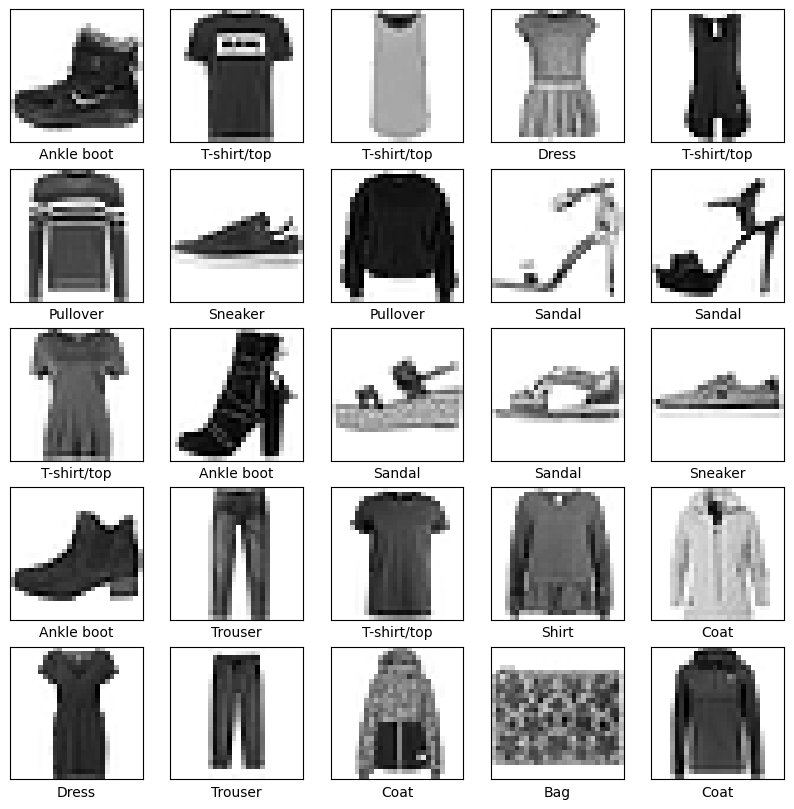

In [77]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].squeeze(), cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i].argmax()])
plt.show()

### 3. Define the 2D CNN Model

In [78]:
# Create a sequential model
model_2d = models.Sequential()

# Add an input layer
model_2d.add(layers.InputLayer(input_shape=(28, 28, 1)))

# Add convolutional and Pooling layers
model_2d.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_2d.add(layers.MaxPooling2D((3, 3)))
model_2d.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_2d.add(layers.MaxPooling2D((2, 2)))

# Flatten the output to feed into fully connected layers
model_2d.add(layers.Flatten())

# Add a dense
model_2d.add(layers.Dense(128, activation='relu'))

# Add the output layer with 10 units and softmax activation
model_2d.add(layers.Dense(10, activation='softmax'))


### 4. Compile, Train, and Evaluate the Model

In [79]:
# Configure the training process
model_2d.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_2d.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,962 (367.04 KB)

 Trainable params: 93,962 (367.04 KB)

 Non-trainable params: 0 (0.00 B)

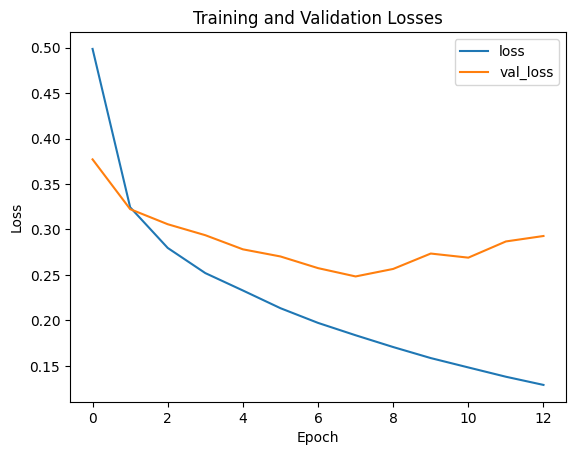

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9533 - loss: 0.1266 - val_accuracy: 0.9103 - val_loss: 0.2928
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.


In [80]:
# Train the model using the training data
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_2d = model_2d.fit(train_images, train_labels, epochs=20, validation_data=(test_images, test_labels),
                           callbacks=[early_stopping, PlotLosses()], verbose=1)


In [60]:
# Evaluate the model on the test data
test_loss, test_accuracy = model_2d.evaluate(test_images, test_labels, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.2482
Test accuracy: 0.9096


### 5. Plot Training History

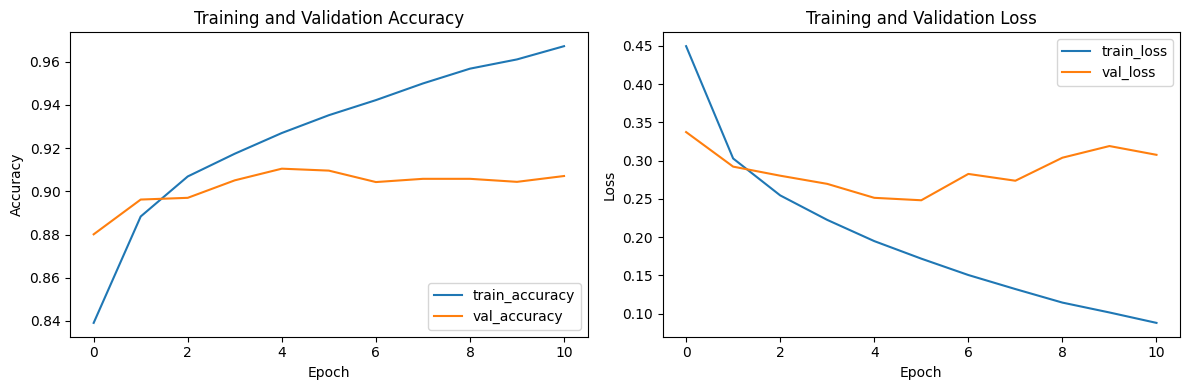

In [61]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_2d.history['accuracy'], label='train_accuracy')
plt.plot(history_2d.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_2d.history['loss'], label='train_loss')
plt.plot(history_2d.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

# Part 2: 1D CNN for Signal Analysis (Simple Synthetic Dataset)

### 1. Create a Simple Synthetic 1D Signal Dataset

Let's create two classes of simple time series signals with added random noise:

Class 0: Sine waves with increasing frequency

Class 1: Cosine waves with decreasing frequency

In [65]:
def generate_sine_wave(length, start_freq, end_freq):
    time = np.linspace(0, 1, length, endpoint=False)
    frequency = np.linspace(start_freq, end_freq, length)
    return np.sin(2 * np.pi * frequency * time)

def generate_cosine_wave(length, start_freq, end_freq):
    time = np.linspace(0, 1, length, endpoint=False)
    frequency = np.linspace(start_freq, end_freq, length)
    return np.cos(2 * np.pi * frequency * time)

def add_noise(signal, noise_level=0.1):
    noise = np.random.normal(0, noise_level, len(signal))
    return signal + noise

In [66]:
num_samples = 1000
signal_length = 128
noise_amplitude = 0.2

# Generate data for Class 0 (Sine waves with noise)
signals_0 = np.array([add_noise(generate_sine_wave(signal_length, 1, 10), noise_amplitude) for _ in range(num_samples // 2)])
labels_0 = np.zeros(num_samples // 2)

# Generate data for Class 1 (Cosine waves with noise)
signals_1 = np.array([add_noise(generate_cosine_wave(signal_length, 10, 1), noise_amplitude) for _ in range(num_samples // 2)])
labels_1 = np.ones(num_samples // 2)

# Combine data and labels
signals = np.concatenate([signals_0, signals_1], axis=0)
labels = np.concatenate([labels_0, labels_1], axis=0)

# Add a channel dimension (required for 1D CNN input)
signals = signals[:, :, np.newaxis]

# Convert labels to one-hot encoding
labels = to_categorical(labels)

# Split data into training and testing sets
train_signals, test_signals, train_labels, test_labels = train_test_split(
    signals, labels, test_size=0.2, random_state=42)

# Print the shape of the data
print("Train signals shape:", train_signals.shape)
print("Train labels shape:", train_labels.shape)
print("Test signals shape:", test_signals.shape)
print("Test labels shape:", test_labels.shape)


Train signals shape: (800, 128, 1)
Train labels shape: (800, 2)
Test signals shape: (200, 128, 1)
Test labels shape: (200, 2)


### 2. Visualize a Few Example Signals

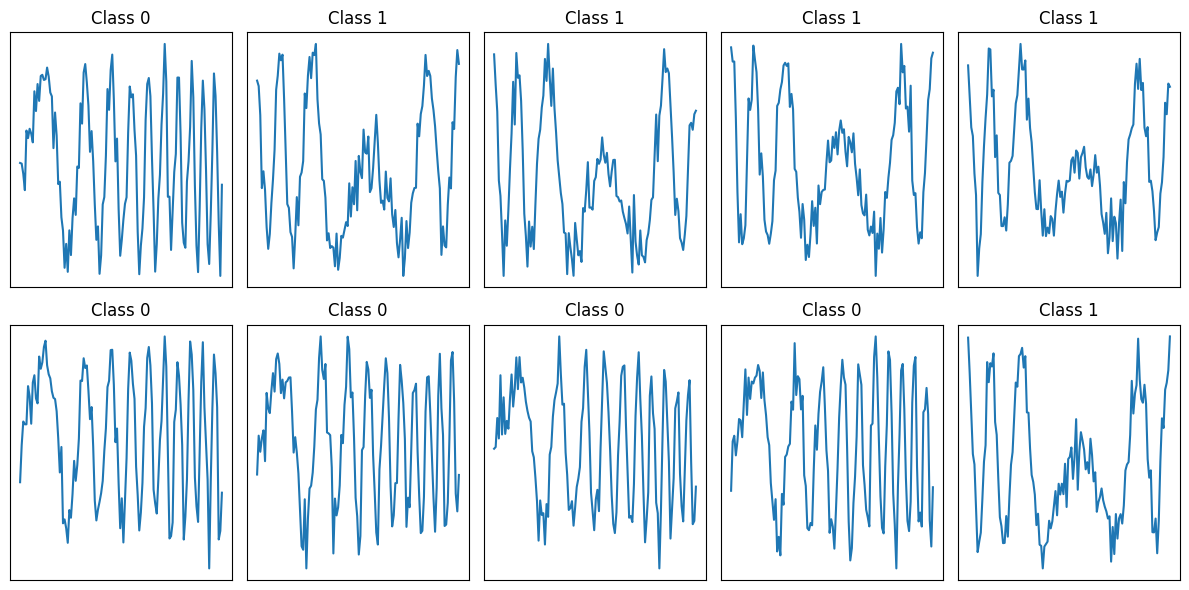

In [67]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.plot(train_signals[i].squeeze())
    plt.title(f"Class {train_labels[i].argmax()}")
    plt.xticks([])
    plt.yticks([])

    plt.subplot(2, 5, i + 6)
    plt.plot(train_signals[len(train_signals) // 2 + i].squeeze())
    plt.title(f"Class {train_labels[len(train_signals) // 2 + i].argmax()}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

### 3. Define the 1D CNN Model

In [68]:
# Create a sequential model
model_1d = models.Sequential()

# Add an input layer
model_1d.add(layers.InputLayer(input_shape=(signal_length, 1)))

# Add a 1D convolutional and Pooling layer
model_1d.add(layers.Conv1D(32, 5, activation='relu'))
model_1d.add(layers.MaxPooling1D(2))
model_1d.add(layers.Conv1D(64, 5, activation='relu'))
model_1d.add(layers.MaxPooling1D(2))

# Flatten the output
model_1d.add(layers.Flatten())

# Add a dense layer
model_1d.add(layers.Dense(64, activation='relu'))

# Add the output layer with 2 units and softmax activation
model_1d.add(layers.Dense(2, activation='softmax'))


### 4. Compile, Train, and Evaluate the Model

In [69]:
model_1d.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_1d.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 124, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 58, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,474 (505.76 KB)

 Trainable params: 129,474 (505.76 KB)

 Non-trainable params: 0 (0.00 B)

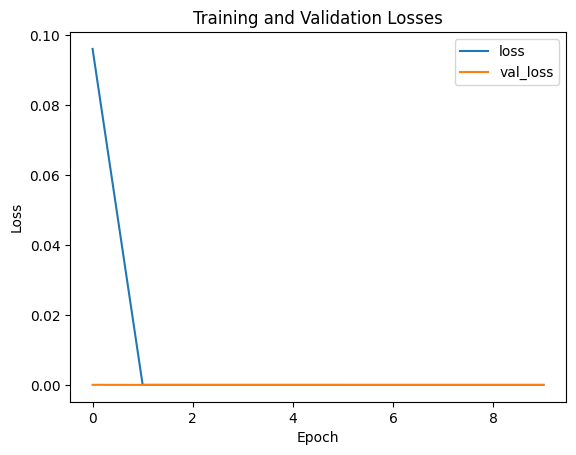

Restoring model weights from the end of the best epoch: 10.


In [70]:
early_stopping_1d = EarlyStopping(monitor='val_loss',
                                   patience=3, restore_best_weights=True, verbose=1)

history_1d = model_1d.fit(train_signals, train_labels, epochs=10,
                            validation_data=(test_signals, test_labels),
                            callbacks=[early_stopping_1d, PlotLosses()],
                            verbose=0)

In [71]:
test_loss_1d, test_accuracy_1d = model_1d.evaluate(test_signals, test_labels, verbose=0)
print(f"Test loss (1D CNN): {test_loss_1d:.2f}")
print(f"Test accuracy (1D CNN): {test_accuracy_1d:.2f}")

Test loss (1D CNN): 0.00
Test accuracy (1D CNN): 1.00


### 5. Plot Training History (1D CNN)

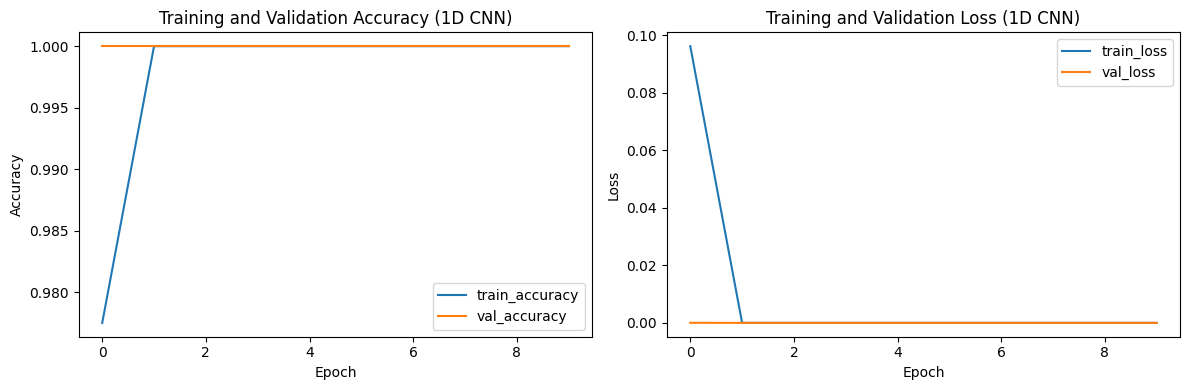

In [72]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_1d.history['accuracy'], label='train_accuracy')
plt.plot(history_1d.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (1D CNN)')

plt.subplot(1, 2, 2)
plt.plot(history_1d.history['loss'], label='train_loss')
plt.plot(history_1d.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (1D CNN)')

plt.tight_layout()
plt.show()